In [3]:
import pandas as pd
url = 'https://raw.githubusercontent.com/kanetkar/LULML/refs/heads/main/ch06/Social_Network_Ads.csv'
df = pd.read_csv(url)
df = df.iloc[:, 2:]
print(df.head( ))


   Age  EstimatedSalary  Purchased
0   19            19000          0
1   35            20000          0
2   26            43000          0
3   27            57000          0
4   19            76000          0


In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Purchased',
			 axis = 1), df['Purchased'], test_size = 0.3, random_state = 0)
print(X_train.shape, X_test.shape)


(280, 2) (120, 2)


In [7]:
from sklearn.preprocessing import StandardScaler

# create instance
scaler = StandardScaler( )

# fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)

# transform train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# convert scaled arrays back to DataFrames
X_train_scaled_df = pd.DataFrame(X_train_scaled,
					columns = X_train.columns, index = X_train.index)
X_test_scaled_df  = pd.DataFrame(X_test_scaled,
					columns = X_test.columns,  index = X_test.index)

# print first few rows
print(X_train_scaled_df.head( ))
print(X_test_scaled_df.head( ))

print("Train means and stddev:")
print(X_train_scaled_df.mean( ).round(4))
print(X_train_scaled_df.std( ).round(4))

print("\nTest means and stddev:")
print(X_test_scaled_df.mean().round(4))
print(X_test_scaled_df.std().round(4))


          Age  EstimatedSalary
92  -1.163172        -1.584970
223  2.170181         0.930987
234  0.013305         1.220177
232  0.209385         1.075582
377  0.405465        -0.486047
          Age  EstimatedSalary
132 -0.771013         0.497201
309  0.013305        -0.572804
341 -0.280814         0.150172
196 -0.771013         0.265849
246 -0.280814        -0.572804
Train means and stddev:
Age                0.0
EstimatedSalary    0.0
dtype: float64
Age                1.0018
EstimatedSalary    1.0018
dtype: float64

Test means and stddev:
Age               -0.0684
EstimatedSalary   -0.0062
dtype: float64
Age                1.0887
EstimatedSalary    0.9524
dtype: float64


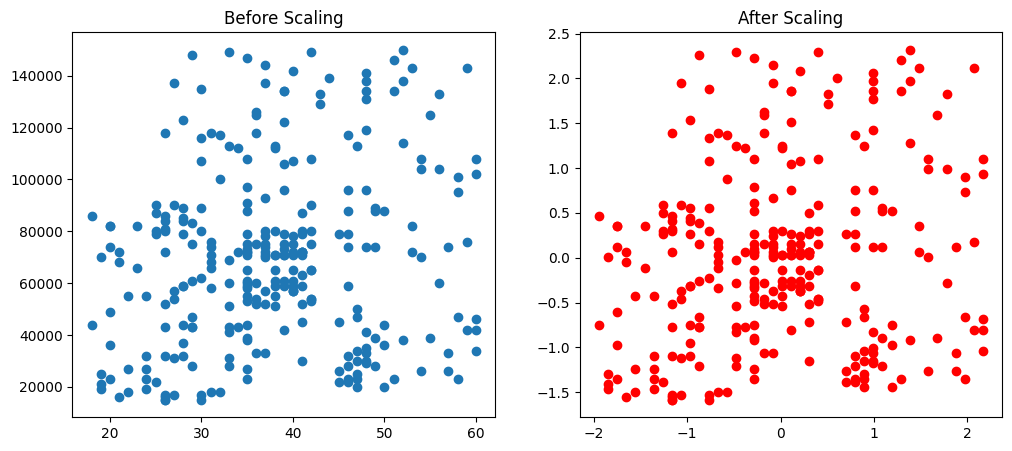

In [8]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(ncols = 2, figsize = (12, 5))
ax1.scatter(X_train['Age'], X_train['EstimatedSalary'])
ax1.set_title("Before Scaling")

ax2.scatter(X_train_scaled_df['Age'], X_train_scaled_df['EstimatedSalary'], color = 'red')
ax2.set_title("After Scaling")

plt.show( )


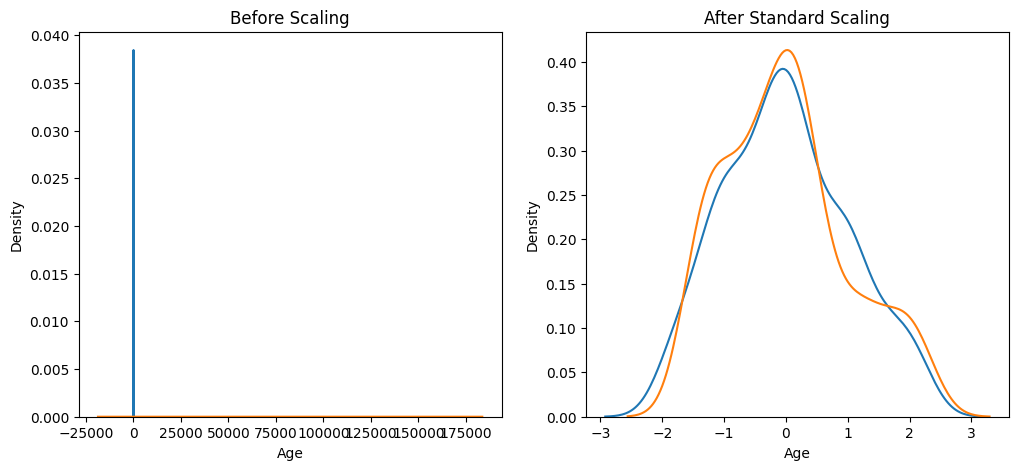

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, (ax1, ax2) = plt.subplots(ncols = 2, figsize = (12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Age'], ax = ax1)
sns.kdeplot(X_train['EstimatedSalary'], ax = ax1)

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(X_train_scaled_df['Age'], ax = ax2)
sns.kdeplot(X_train_scaled_df['EstimatedSalary'], ax = ax2)

plt.show( )


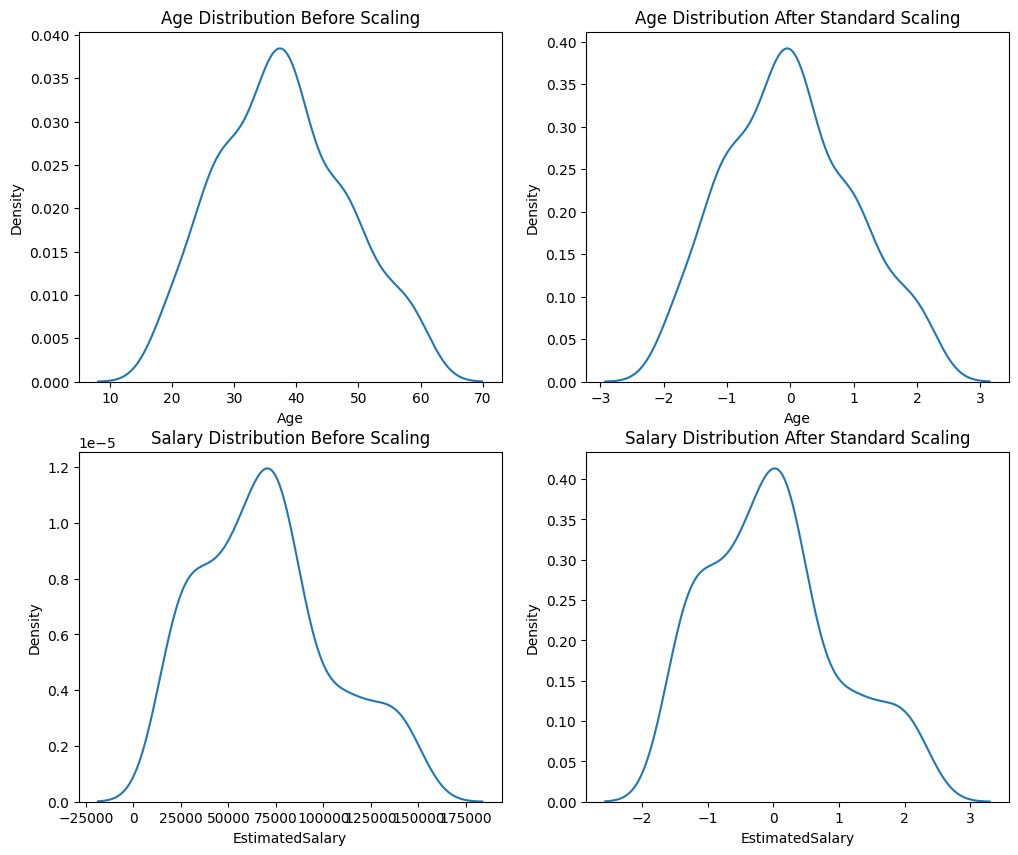

In [12]:
# create a 2x2 subplot layout
fig, axes = plt.subplots(nrows = 2, ncols = 2, figsize = (12, 10))

# Age distribution before scaling
axes[0, 0].set_title('Age Distribution Before Scaling')
sns.kdeplot(X_train['Age'], ax = axes[0, 0])

# Age distribution after scaling
axes[0, 1].set_title('Age Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled_df['Age'], ax = axes[0, 1])

# EstimatedSalary distribution before scaling
axes[1, 0].set_title('Salary Distribution Before Scaling')
sns.kdeplot(X_train['EstimatedSalary'], ax = axes[1, 0])

# EstimatedSalary distribution after scaling
axes[1, 1].set_title('Salary Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled_df['EstimatedSalary'], ax = axes[1, 1])

plt.show( )
